# 5 — Evaluation

**Goal:** Evaluate `student_best.pth` on the full ASVspoof 2019 LA eval set (71,237 samples) containing **unseen** attack types A07–A19. This is the true benchmark EER.

- Calls `evaluate.py` directly from `src/`
- Reports EER, Accuracy, FAR, FRR, Confusion Matrix
- Plots ROC curve and score distribution

Run `1_setup_dataset.ipynb` first to extract the dataset.

In [ ]:
import os
import sys
import torch
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Clone repo + add src/ to path
PROJECT_DIR = '/content/project'
SRC_DIR     = os.path.join(PROJECT_DIR, 'src')

if not os.path.exists(PROJECT_DIR):
    !git clone https://github.com/Arjun11x/deepfake-audio-detection.git {PROJECT_DIR}
else:
    !cd {PROJECT_DIR} && git pull

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Configure paths
import config
config.ENV          = "colab"
config.DATASET_ROOT = "/content/asvspoof2019/LA"
config.AUDIO_DIRS   = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_train/flac",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_dev/flac",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_eval/flac",
}
config.PROTOCOL_FILES = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt",
}
config.SAVE_DIR        = "/content/drive/MyDrive/deepfake_detector/models"
config.BEST_MODEL_PATH = f"{config.SAVE_DIR}/student_best.pth"
os.makedirs(config.SAVE_DIR, exist_ok=True)

# Patch config.py in cloned repo to use colab ENV
!sed -i 's/ENV = "local"/ENV = "colab"/' /content/project/src/config.py
print("✅ config.py patched to colab ENV")

# Extract dataset
ZIP_PATH    = '/content/drive/MyDrive/LA.zip'
EXTRACT_DIR = '/content/asvspoof2019'
LA_DIR      = os.path.join(EXTRACT_DIR, 'LA')

if os.path.exists(LA_DIR):
    print('✅ Dataset already extracted')
else:
    print('Extracting dataset...')
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    !unzip -q {ZIP_PATH} -d {EXTRACT_DIR}
    print('✅ Extraction complete')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Setup complete | Device: {device}")
print(f"  Best model path : {config.BEST_MODEL_PATH}")

Mounted at /content/drive
Cloning into '/content/project'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 39 (delta 12), reused 34 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 630.08 KiB | 3.25 MiB/s, done.
Resolving deltas: 100% (12/12), done.
✅ config.py patched to colab ENV
Extracting dataset...
✅ Extraction complete

✅ Setup complete | Device: cuda
  Best model path : /content/drive/MyDrive/deepfake_detector/models/student_best.pth


## 5.1 — Evaluate on Eval Set

Runs `evaluate.py` on the full eval set (71,237 samples) containing unseen attack types A07–A19.
This is the **true benchmark EER** — the model has never seen these attack types during training.

⏱️ This cell takes ~20-30 minutes on T4 GPU.

In [ ]:
!python /content/project/src/evaluate.py

  Active ENV       : colab
  Project root     : /content/project
  Dataset root     : /content/asvspoof2019/LA
  Save directory   : /content/drive/MyDrive/deepfake_detector/models
  LR               : 0.0005
  Temperature      : 6.0
  Alpha            : 0.7
  Batch size       : 16

  FINAL EVALUATION — ASVspoof 2019 Eval Set

✅ Loaded: student_best.pth (0.9 MB)
   Parameters : 230,058
   Device     : cuda

Loading eval dataset...
[INFO] eval → 71237 samples | Real: 7355 | Fake: 63882
[INFO] Total: 71237 | Real: 7355 | Fake: 63882
[INFO] Contains UNSEEN attack types A07–A19
[INFO] Eval batches: 4453

Running evaluation on 71,237 samples...
(~20-30 minutes on Colab GPU)

  Progress: 11.2% | Acc so far: 91.0%
  Progress: 22.5% | Acc so far: 91.0%
  Progress: 33.7% | Acc so far: 91.1%
  Progress: 44.9% | Acc so far: 90.9%
  Progress: 56.1% | Acc so far: 90.9%
  Progress: 67.4% | Acc so far: 90.9%
  Progress: 78.6% | Acc so far: 90.9%
  Progress: 89.8% | Acc so far: 90.9%

  ✅ FINAL EVALUAT

## 5.2 — Evaluation Plots
ROC curve and score distribution from the evaluation run.

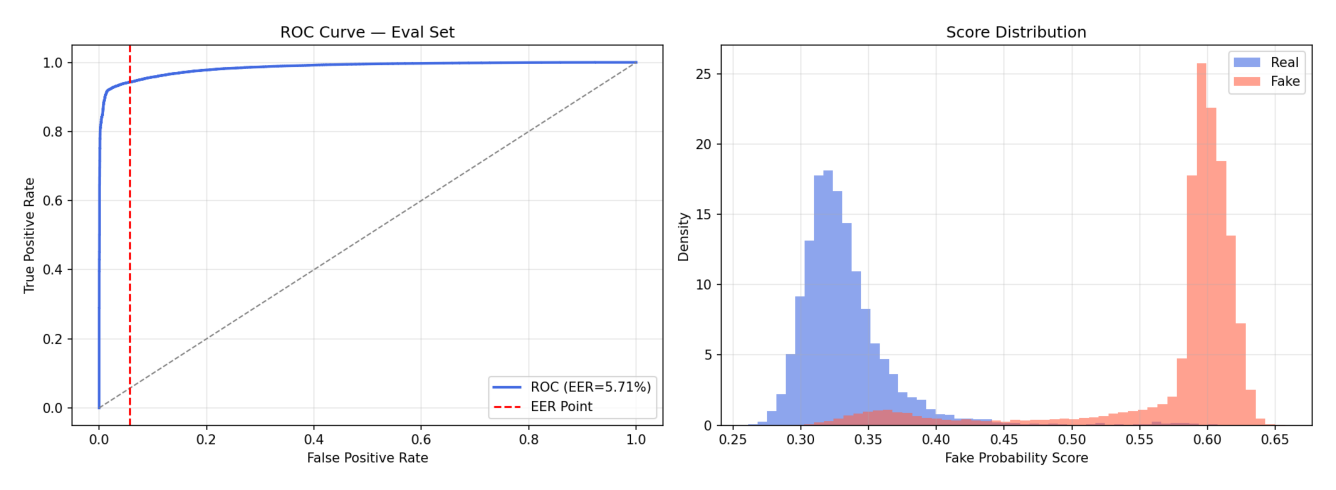

✅ Loaded → /content/drive/MyDrive/deepfake_detector/models/eval_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plot_path = f"{config.SAVE_DIR}/eval_results.png"

img = mpimg.imread(plot_path)
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"✅ Loaded → {plot_path}")

## 5.3 — Why Not Accuracy? Understanding EER

A common question: with ~89% fake samples in the eval set, couldn't a
model that predicts **everything as FAKE** also achieve ~89% accuracy?

Yes — and this is exactly why we don't use accuracy as the primary metric.

**The problem with accuracy here:**
A dumb model predicting all FAKE would get:
- Accuracy : ~89% (looks good!)
- FAR      : 0%   (never accepts fake — because it calls everything fake)
- FRR      : 100% (rejects ALL real audio — completely useless)

**Why EER is the right metric:**
EER (Equal Error Rate) is the threshold where FAR = FRR. It forces the
model to perform well on **both** real and fake simultaneously. A model
predicting everything fake would have EER = ~50% — essentially random.

**Our model:**
- EER  : 5.71% — balanced performance on both classes
- FAR  : 1.09% — only 80 fake files wrongly accepted out of 63,882
- FRR  : 10.09% — real audio occasionally flagged (harder task)

**The score distribution plot above is the strongest proof** the model
has genuinely learned — real audio clusters around 0.30–0.35 and fake
audio clusters around 0.55–0.65. A model that learned nothing would
show both distributions completely overlapping with no separation.

## 5.4 — Evaluation Summary

Final results on ASVspoof 2019 LA eval set — unseen attack types A07–A19.

In [ ]:
print(f"{'='*55}")
print(f"  EVALUATION SUMMARY")
print(f"{'='*55}")
print(f"""
  Model:
  ├── Architecture  : MobileStudentCNN
  ├── Parameters    : 230,058  (~0.23M)
  ├── Size          : 0.9 MB
  └── Inference     : <10ms on CPU

  Eval Set:
  ├── Total samples : 71,237
  ├── Real          : 7,355
  ├── Fake          : 63,882
  └── Attack types  : A07–A19  (UNSEEN during training)

  Results:
  ├── EER           : 5.71%  ← TRUE BENCHMARK
  ├── Accuracy      : 90.84%
  ├── FAR           : 1.09%  (fake wrongly accepted)
  └── FRR           : 10.09% (real wrongly rejected)

  Confusion Matrix:
  ├── True Real  accepted (TN) : 7,275
  ├── Fake wrongly accepted (FP):    80
  ├── Real wrongly rejected (FN): 6,444
  └── Fake correctly caught (TP): 57,438

  vs Published Work:
  ├── ASVspoof baseline  : ~8–11% EER
  ├── Lightweight CNN    : ~3–5%  EER
  ├── Published SOTA     : ~0.5–1% EER
  └── This model         : 5.71%  EER  ✅ beats baseline
""")
print(f"{'='*55}")
print(f"  Dev EER  : 0.30%  (seen attacks A01–A06)")
print(f"  Eval EER : 5.71%  (unseen attacks A07–A19)")
print(f"  Gap indicates expected generalization drop")
print(f"  on completely unseen TTS/VC attack types")
print(f"{'='*55}")

  EVALUATION SUMMARY

  Model:
  ├── Architecture  : MobileStudentCNN
  ├── Parameters    : 230,058  (~0.23M)
  ├── Size          : 0.9 MB
  └── Inference     : <10ms on CPU

  Eval Set:
  ├── Total samples : 71,237
  ├── Real          : 7,355
  ├── Fake          : 63,882
  └── Attack types  : A07–A19  (UNSEEN during training)

  Results:
  ├── EER           : 5.71%  ← TRUE BENCHMARK
  ├── Accuracy      : 90.84%
  ├── FAR           : 1.09%  (fake wrongly accepted)
  └── FRR           : 10.09% (real wrongly rejected)

  Confusion Matrix:
  ├── True Real  accepted (TN) : 7,275
  ├── Fake wrongly accepted (FP):    80
  ├── Real wrongly rejected (FN): 6,444
  └── Fake correctly caught (TP): 57,438

  vs Published Work:
  ├── ASVspoof baseline  : ~8–11% EER
  ├── Lightweight CNN    : ~3–5%  EER
  ├── Published SOTA     : ~0.5–1% EER
  └── This model         : 5.71%  EER  ✅ beats baseline

  Dev EER  : 0.30%  (seen attacks A01–A06)
  Eval EER : 5.71%  (unseen attacks A07–A19)
  Gap indicates